# 신용카드 고객 이탈 예측 — 4. 회귀 (완성본)

타겟: `Total_Trans_Ct` (최근 12개월 총 거래건수)

**전체 흐름**
1. 데이터 로드 & Train(60%)/Validation(20%)/Test(20%) 분할
2. 베이스라인 → **고도화**(피처 엔지니어링 → 하이퍼파라미터 튜닝 → 앙상블)
3. 최종 모델 확정 (Validation 기준 선택 · Test는 한 번만 평가)
4. **핵심 분석**: 거래금액 변수(`Total_Trans_Amt`)의 함정 — 금액 포함(A) vs 제외(B)
5. **Ablation**: 왜 R²가 0.3에 머무는가 (데이터의 정보 한계 증명)
6. **최종 선택 & 비즈니스 적용**: 활동성 갭 기반 이탈 조기경보 (모델 B)

> 핵심 메시지: **R²가 높은 모델 ≠ 목적에 맞는 모델.** 이탈 조기경보라는 목적에서는
> 거래금액을 뺀 모델(B)이 R²는 낮아도 실무적으로 더 유효하다.

## 0. 라이브러리 & 데이터 로드

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import itertools, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              VotingRegressor, StackingRegressor)
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


for _p in ["../data/processed/bankchurners_clean.csv",
           "data/processed/bankchurners_clean.csv",
           "data/bankchurners_clean.csv", "churn.csv"]:
    if os.path.exists(_p):
        DATA_PATH = _p; break
df = pd.read_csv(DATA_PATH)
y = df["Total_Trans_Ct"]
print("데이터:", DATA_PATH, df.shape)

데이터: ../data/processed/bankchurners_clean.csv (10127, 20)


### 차트 공통 테마

이 노트북의 모든 그림이 한 벌로 읽히도록 색·그리드·마크 규칙을 한 곳에서 정의한다.

- **파랑(슬롯1) = 모델 A / Validation**, **주황(슬롯2) = 모델 B / Test** — 색은 *역할(엔티티)* 을 따라가며, 정렬 순서에 따라 바뀌지 않는다.
- 그리드·축은 배경과 한 톤 차이의 **실선 헤어라인**, 마크는 얇게, 값은 **선별적으로만** 직접 라벨링한다.
- 상태색(빨강)은 "위험·반칙(누수)" 의미로만 쓰고 시리즈 색으로는 재사용하지 않는다.

In [2]:
# ── 색 슬롯 (카테고리형은 고정 순서로만 사용, 절대 순환/생성하지 않는다) ──────────
SURFACE  = "#fcfcfb"   # 차트 배경
INK      = "#0b0b0b"   # 기본 텍스트
INK_SUB  = "#52514e"   # 보조 텍스트
MUTED    = "#898781"   # 축/눈금 라벨
GRID     = "#e1e0d9"   # 그리드 헤어라인
AXIS     = "#c3c2b7"   # 축선/연결선

BLUE     = "#2a78d6"   # 슬롯1 — 모델 A / Validation / 기준
ORANGE   = "#eb6834"   # 슬롯2 — 모델 B / Test / 실측
BLUE_DIM = "#9ec5f4"   # 슬롯1의 연한 단계 (강조 대비용)
CRITICAL = "#d03b3b"   # 상태색: 위험·반칙(누수)  ※ 시리즈 색으로는 쓰지 않음
GOOD     = "#0ca30c"   # 상태색: 개선

matplotlib.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.labelcolor": INK_SUB, "axes.labelsize": 10,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",   # 그리드는 실선 헤어라인
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "legend.fontsize": 9.5,
})

def style_ax(ax, xgrid=False, ygrid=True):
    """상·우 스파인 제거 + 필요한 방향의 그리드만 남기는 공통 정리."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.grid(axis="y", visible=ygrid)
    ax.grid(axis="x", visible=xgrid)
    return ax

print("차트 테마 적용 완료")

차트 테마 적용 완료


## 1. 공통 함수 정의

`make_features`로 파생변수 추가 + (옵션) `Total_Trans_Amt` 제거를 한 곳에서 처리하고,
`split_60_20_20`으로 항상 같은 고객이 같은 Train/Val/Test에 들어가도록 고정한다.

In [3]:
def make_features(drop_amount=False, fe=True):
    """파생변수(4개) 추가 후 원-핫. drop_amount=True면 Total_Trans_Amt 제거."""
    d = df.copy()
    if fe:
        d["리볼빙_한도_비율"]  = d["Total_Revolving_Bal"] / d["Credit_Limit"]
        d["상품당_관계밀도"]    = d["Total_Relationship_Count"] / d["Months_on_book"]
        d["문의_대비_보유기간"] = d["Contacts_Count_12_mon"] / d["Months_on_book"]
        d["연령대"] = pd.cut(d["Customer_Age"], bins=[0,30,40,50,60,100],
                            labels=["20대이하","30대","40대","50대","60대이상"])
    drop = ["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"]
    if drop_amount:
        drop.append("Total_Trans_Amt")
    X = d.drop(columns=drop)
    cat = X.select_dtypes(include=["object", "category"]).columns.tolist()
    return pd.get_dummies(X, columns=cat, drop_first=True)

def split_60_20_20(X):
    """train_test_split 2회로 60/20/20 (random_state=42 고정)."""
    Xtv, Xte, ytv, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    Xtr, Xva, ytr, yva = train_test_split(Xtv, ytv, test_size=0.25, random_state=42)
    return Xtr, Xva, Xte, ytr, yva, yte, Xtv, ytv

# 튜닝으로 찾은 XGBoost 기본 파라미터(아래 4번에서 재확인)
XGB_BEST = dict(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.8, random_state=42)

## 2. Train/Validation/Test 분할 & 베이스라인

원본 피처(파생변수 없음, **금액 포함**)로 세 모델의 기본 성능을 확인한다.
이후 고도화 단계는 같은 고객(같은 인덱스) 기준으로 진행한다.

In [4]:
X_raw = make_features(drop_amount=False, fe=False)
Xtr, Xva, Xte, ytr, yva, yte, Xtv, ytv = split_60_20_20(X_raw)
print(f"Train {len(Xtr)}(60%) / Val {len(Xva)}(20%) / Test {len(Xte)}(20%)")

sc = StandardScaler()
lr_base  = LinearRegression().fit(sc.fit_transform(Xtr), ytr)
rf_base  = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)
xgb_base = XGBRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)

pd.DataFrame([
    {"Model": "Linear Regression", "Val_R2": r2_score(yva, lr_base.predict(sc.transform(Xva)))},
    {"Model": "Random Forest",     "Val_R2": r2_score(yva, rf_base.predict(Xva))},
    {"Model": "XGBoost",           "Val_R2": r2_score(yva, xgb_base.predict(Xva))},
]).round(4)

Train 6075(60%) / Val 2026(20%) / Test 2026(20%)


,Model,Val_R2
0,Linear Regression,0.6731
1,Random Forest,0.8639
2,XGBoost,0.8388


---
# 고도화

피처 엔지니어링 → 하이퍼파라미터 튜닝 → 앙상블 순서로 진행. 각 단계는 Validation으로 확인하고 Test는 6번에서 한 번만 평가한다.

## 3. 고도화① 피처 엔지니어링

거래건수(타겟)와 순환관계가 생기지 않도록 **거래금액 파생변수는 만들지 않고** 비율·구간 위주 4개를 추가한다.
(주의: 원본 `Total_Trans_Amt`는 이 단계에서는 아직 포함되어 있다 — 이 변수의 영향은 8번에서 집중 분석한다.)

In [5]:
X = make_features(drop_amount=False, fe=True)   # 파생변수 추가 + 금액 포함
Xtr, Xva, Xte, ytr, yva, yte, Xtv, ytv = split_60_20_20(X)

xgb_fe = XGBRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)
# 원본/FE는 인덱스가 동일하므로, 같은 Val 고객에 대해 두 모델을 비교
pd.DataFrame([
    {"버전": "원본 피처만",   "Val_R2": r2_score(yva, xgb_base.predict(X_raw.loc[Xva.index]))},
    {"버전": "파생변수 추가", "Val_R2": r2_score(yva, xgb_fe.predict(Xva))},
]).round(4)

,버전,Val_R2
0,원본 피처만,0.8388
1,파생변수 추가,0.8396


## 4. 고도화② 하이퍼파라미터 튜닝

네 가지 방법을 비교한다. CV 계열은 Train+Val(80%)에서 탐색한 뒤, 공정 비교를 위해 같은 파라미터로
Train(60%)만 다시 학습해 Validation을 평가한다.

In [6]:
# 4-1. 수동 Validation 탐색
grid = {"n_estimators":[200,500], "max_depth":[5,7], "learning_rate":[0.01,0.05], "subsample":[0.8,1.0]}
keys, vals = zip(*grid.items())
rows = []
for combo in itertools.product(*vals):
    p = dict(zip(keys, combo))
    m = XGBRegressor(random_state=42, **p).fit(Xtr, ytr)
    rows.append({**p, "Val_R2": r2_score(yva, m.predict(Xva))})
best_manual = pd.DataFrame(rows).sort_values("Val_R2", ascending=False).iloc[0][list(grid)].to_dict()
best_manual = {k:(int(v) if k in ["n_estimators","max_depth"] else v) for k,v in best_manual.items()}
manual_model = XGBRegressor(random_state=42, **best_manual).fit(Xtr, ytr)
manual_val = r2_score(yva, manual_model.predict(Xva))
print("수동 최적:", best_manual, "-> Val R2", round(manual_val,4))

수동 최적: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8} -> Val R2 0.8645


In [7]:
# 4-2. RandomizedSearchCV
dist = {"n_estimators":[100,200,300,500], "max_depth":[3,5,7,10],
        "learning_rate":[0.01,0.05,0.1,0.2], "subsample":[0.7,0.8,1.0], "colsample_bytree":[0.7,0.8,1.0]}
rs = RandomizedSearchCV(XGBRegressor(random_state=42), dist, n_iter=8, scoring="r2",
                        cv=3, random_state=42, n_jobs=-1).fit(Xtv, ytv)
random_model = XGBRegressor(random_state=42, **rs.best_params_).fit(Xtr, ytr)
random_val = r2_score(yva, random_model.predict(Xva))
print("Randomized 최적:", rs.best_params_, "-> Val R2", round(random_val,4))

# 4-3. GridSearchCV
gp = {"n_estimators":[200,500], "max_depth":[5,7], "learning_rate":[0.01,0.05], "subsample":[0.8]}
gs = GridSearchCV(XGBRegressor(random_state=42), gp, scoring="r2", cv=3, n_jobs=-1).fit(Xtv, ytv)
grid_model = XGBRegressor(random_state=42, **gs.best_params_).fit(Xtr, ytr)
grid_val = r2_score(yva, grid_model.predict(Xva))
print("Grid 최적:", gs.best_params_, "-> Val R2", round(grid_val,4))

# 4-4. Optuna
def objective(trial):
    p = {"n_estimators": trial.suggest_int("n_estimators",100,600,step=100),
         "max_depth": trial.suggest_int("max_depth",3,10),
         "learning_rate": trial.suggest_float("learning_rate",0.01,0.2,log=True),
         "subsample": trial.suggest_float("subsample",0.6,1.0),
         "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0)}
    return cross_val_score(XGBRegressor(random_state=42, **p), Xtv, ytv, cv=3, scoring="r2").mean()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=12, show_progress_bar=False)
optuna_model = XGBRegressor(random_state=42, **study.best_params).fit(Xtr, ytr)
optuna_val = r2_score(yva, optuna_model.predict(Xva))
print("Optuna 최적:", study.best_params, "-> Val R2", round(optuna_val,4))

Randomized 최적: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0} -> Val R2 0.8601
Grid 최적: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8} -> Val R2 0.8645
Optuna 최적: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.012151617026673379, 'subsample': 0.9795542149013333, 'colsample_bytree': 0.9862528132298237} -> Val R2 0.8615


## 5. 고도화③ 앙상블

튜닝된 XGBoost에 RandomForest·GradientBoosting·LightGBM을 더해 Voting/Stacking을 시도한다.
(참고: 아래 결과처럼 앙상블 이득은 단일 모델 대비 **미세**하다 — 정직하게 기록한다.)

In [8]:
rf_t   = RandomForestRegressor(n_estimators=150, random_state=42).fit(Xtr, ytr)
gbr_t  = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.03, random_state=42).fit(Xtr, ytr)
lgbm_t = LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1).fit(Xtr, ytr)

voting = VotingRegressor([("xgb",manual_model),("rf",rf_t),("gbr",gbr_t),("lgbm",lgbm_t)]).fit(Xtr, ytr)
stacking = StackingRegressor(
    estimators=[("xgb",manual_model),("rf",rf_t),("gbr",gbr_t),("lgbm",lgbm_t)],
    final_estimator=Ridge(alpha=1.0), cv=3).fit(Xtr, ytr)

pd.DataFrame([
    {"모델":"RandomForest",    "Val_R2": r2_score(yva, rf_t.predict(Xva))},
    {"모델":"GradientBoosting","Val_R2": r2_score(yva, gbr_t.predict(Xva))},
    {"모델":"LightGBM",        "Val_R2": r2_score(yva, lgbm_t.predict(Xva))},
    {"모델":"Voting",          "Val_R2": r2_score(yva, voting.predict(Xva))},
    {"모델":"Stacking",        "Val_R2": r2_score(yva, stacking.predict(Xva))},
]).round(4)

,모델,Val_R2
0,RandomForest,0.8629
1,GradientBoosting,0.8650
2,LightGBM,0.8648
3,Voting,0.8666
4,Stacking,0.8666


## 6. 최종 모델 확정 — **Validation 기준 선택** (Test는 한 번만)

> **[버그 수정]** 이전 버전은 `Test_R2`가 가장 높은 모델을 최종으로 골랐는데, 이는 Test로 모델을
> 선택한 것이라 오염이다. 여기서는 **Validation R²로 최종 모델을 고르고**, 그 모델의 Test R²를
> 참고로 병기한다.

In [9]:
candidates = {
    "수동탐색 XGB":   manual_model,
    "Randomized XGB": random_model,
    "Grid XGB":       grid_model,
    "Optuna XGB":     optuna_model,
    "RandomForest":   rf_t,
    "GradientBoost":  gbr_t,
    "LightGBM":       lgbm_t,
    "Voting":         voting,
    "Stacking":       stacking,
}
board = pd.DataFrame([
    {"방법": n, "Val_R2": r2_score(yva, m.predict(Xva)), "Test_R2": r2_score(yte, m.predict(Xte))}
    for n, m in candidates.items()
]).sort_values("Val_R2", ascending=False).reset_index(drop=True)   # ← Val 기준 정렬
display(board.round(4))

final_name  = board.iloc[0]["방법"]         # Val 최고를 최종으로
final_model = candidates[final_name]
print(f"\n최종 선정(Val 기준): {final_name}")
print(f"Train R2 {r2_score(ytr, final_model.predict(Xtr)):.4f} / "
      f"Val R2 {board.iloc[0]['Val_R2']:.4f} / Test R2 {board.iloc[0]['Test_R2']:.4f}")

,방법,Val_R2,Test_R2
0,Voting,0.8666,0.8578
1,Stacking,0.8666,0.8575
2,GradientBoost,0.8650,0.8554
3,LightGBM,0.8648,0.8558
4,수동탐색 XGB,0.8645,0.8560
5,Grid XGB,0.8645,0.8560
6,RandomForest,0.8629,0.8543
7,Optuna XGB,0.8615,0.8529
8,Randomized XGB,0.8601,0.8536



최종 선정(Val 기준): Voting
Train R2 0.9218 / Val R2 0.8666 / Test R2 0.8578


### 6-1. 최적화 결과 한눈에 보기

왼쪽은 **고도화 단계별 향상폭**, 오른쪽은 **후보 모델 9개의 Validation ↔ Test 차이**다.

- 값 차이가 0.03 이내로 작아 0 기준 막대 대신 **확대한 축 + 점(덤벨)** 으로 그린다. 막대를 잘라 그리면 차이가 과장되어 보이기 때문이다.
- 파랑 = Validation(선정 기준), 주황 = Test(참고). 두 점을 잇는 선의 길이가 곧 **일반화 손실**이다.

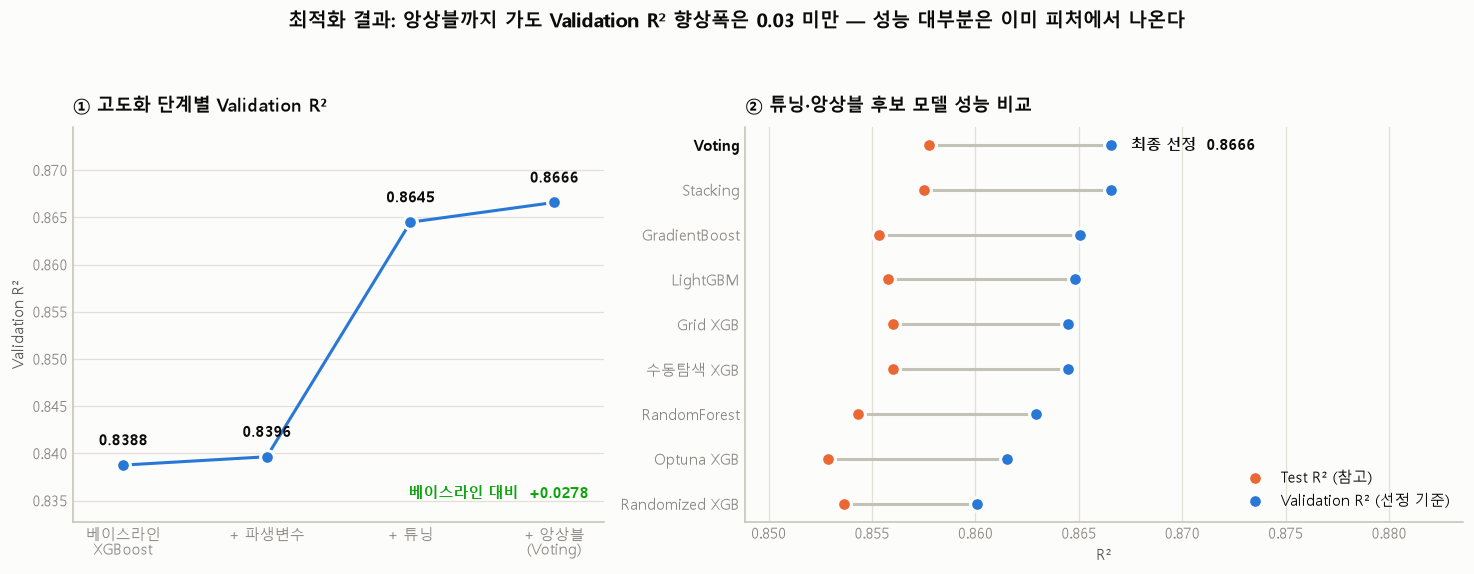

In [10]:
# ── 최적화 후 모델 비교 ────────────────────────────────────────────────
# (좌) 고도화 단계별 Validation R²  (우) 후보 모델별 Validation vs Test R²
stages = [
    ("베이스라인\nXGBoost",   r2_score(yva, xgb_base.predict(X_raw.loc[Xva.index]))),
    ("+ 파생변수",            r2_score(yva, xgb_fe.predict(Xva))),
    ("+ 튜닝",                manual_val),
    ("+ 앙상블\n(Voting)",    r2_score(yva, voting.predict(Xva))),
]
s_lab = [s[0] for s in stages]
s_val = [s[1] for s in stages]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2),
                               gridspec_kw={"width_ratios": [1, 1.35]})

# (좌) 단계별 향상 — 값 차이가 작아 0 기준선 대신 확대한 스케일로 본다
ax1.plot(range(4), s_val, color=BLUE, lw=2, zorder=2)
ax1.plot(range(4), s_val, "o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=3)
for i, v in enumerate(s_val):
    ax1.annotate(f"{v:.4f}", (i, v), textcoords="offset points", xytext=(0, 13),
                 ha="center", fontsize=9.5, color=INK, fontweight="bold")
ax1.text(0.97, 0.06, f"베이스라인 대비  +{s_val[-1] - s_val[0]:.4f}", transform=ax1.transAxes,
         ha="right", fontsize=10, color=GOOD, fontweight="bold")
ax1.set_xticks(range(4)); ax1.set_xticklabels(s_lab)
ax1.set_xlim(-0.35, 3.35)
ax1.set_ylim(min(s_val) - 0.006, max(s_val) + 0.008)
ax1.set_ylabel("Validation R²")
ax1.set_title("① 고도화 단계별 Validation R²", loc="left")
style_ax(ax1)

# (우) 후보 모델 덤벨 차트 — Val(선정 기준)과 Test를 한 줄로 잇는다
b = board.sort_values("Val_R2").reset_index(drop=True)   # 아래→위 오름차순 = 위쪽이 최고
ypos = np.arange(len(b))
ax2.hlines(ypos, b["Test_R2"], b["Val_R2"], color=AXIS, lw=2, zorder=1)
ax2.plot(b["Test_R2"], ypos, "o", ms=9, color=ORANGE, mec=SURFACE, mew=2, zorder=3, label="Test R² (참고)")
ax2.plot(b["Val_R2"],  ypos, "o", ms=9, color=BLUE,   mec=SURFACE, mew=2, zorder=3, label="Validation R² (선정 기준)")

best_i = int(b.index[b["방법"] == final_name][0])
ax2.annotate(f"최종 선정  {b.loc[best_i, 'Val_R2']:.4f}", (b.loc[best_i, "Val_R2"], best_i),
             textcoords="offset points", xytext=(13, 0), va="center",
             fontsize=9.5, color=INK, fontweight="bold")
ax2.set_yticks(ypos); ax2.set_yticklabels(b["방법"])
for t in ax2.get_yticklabels():
    if t.get_text() == final_name:
        t.set_color(INK); t.set_fontweight("bold")
ax2.set_xlim(b["Test_R2"].min() - 0.004, b["Val_R2"].max() + 0.017)
ax2.set_xlabel("R²")
ax2.set_title("② 튜닝·앙상블 후보 모델 성능 비교", loc="left")
ax2.legend(loc="lower right")
style_ax(ax2, xgrid=True, ygrid=False)

fig.suptitle("최적화 결과: 앙상블까지 가도 Validation R² 향상폭은 0.03 미만 — 성능 대부분은 이미 피처에서 나온다",
             y=0.995, fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 7. 최종 모델 Feature Importance — **Permutation Importance**

> **[버그 수정]** 최종 모델이 앙상블(Voting/Stacking)이면 `feature_importances_`가 없다.
> 어떤 모델이든 통하는 **permutation importance**(Validation 기준)로 대체한다.

In [11]:
perm = permutation_importance(final_model, Xva, yva, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(f"[{final_name}] Permutation Importance Top 10")
print(imp.head(10).round(3).to_string())

[Voting] Permutation Importance Top 10
Total_Trans_Amt             1.625
Total_Amt_Chng_Q4_Q1        0.015
Customer_Age                0.013
Marital_Status_Married      0.004
Total_Revolving_Bal         0.003
상품당_관계밀도                    0.002
Credit_Limit                0.002
Avg_Open_To_Buy             0.001
Total_Relationship_Count    0.001
문의_대비_보유기간                  0.001


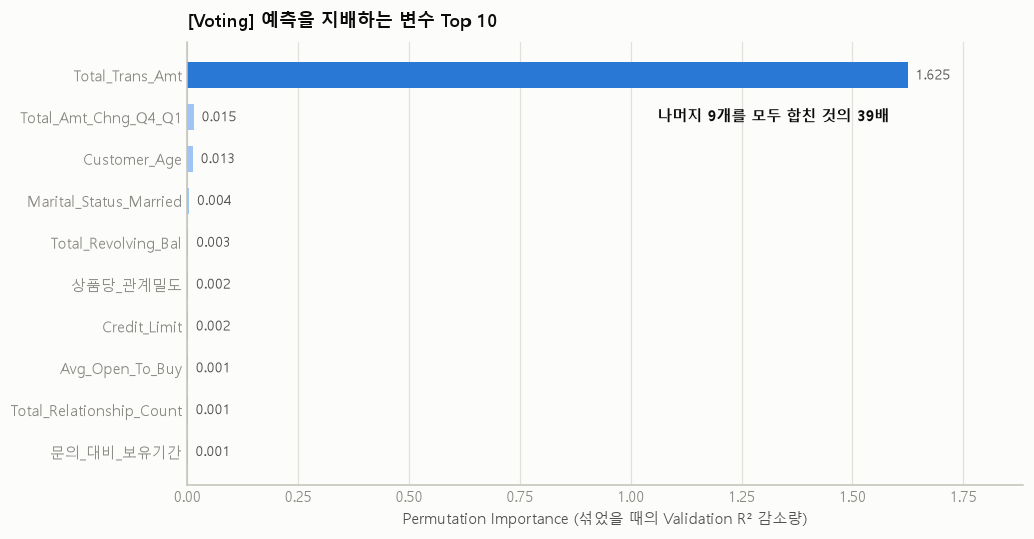

In [12]:
# ── 최종 모델이 실제로 무엇을 보는가 — 한 변수의 독점을 그대로 보여준다 ──────────
top = imp.head(10).sort_values()                  # 아래→위 오름차순
lead = top.index[-1]                              # 1위 변수만 강조, 나머지는 뒤로
colors = [BLUE if n == lead else BLUE_DIM for n in top.index]

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.barh(top.index, top.values, color=colors, height=0.62)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in top.values], padding=5,
             fontsize=9, color=INK_SUB)
ratio = top.iloc[-1] / top.iloc[:-1].sum()
ax.annotate(f"나머지 9개를 모두 합친 것의 {ratio:.0f}배",
            xy=(top.iloc[-1], len(top) - 1), xytext=(-12, -30), textcoords="offset points",
            ha="right", fontsize=10, color=INK, fontweight="bold")
ax.set_xlim(0, top.max() * 1.16)
ax.set_xlabel("Permutation Importance (섞었을 때의 Validation R² 감소량)")
ax.set_title(f"[{final_name}] 예측을 지배하는 변수 Top 10", loc="left")
style_ax(ax, xgrid=True, ygrid=False)
fig.tight_layout(); plt.show()

`Total_Trans_Amt`가 압도적 1위로 나올 것이다. 이것이 **높은 R²의 실체**이며, 8번에서 이 변수를 정면으로 다룬다.

## 8. 핵심 분석 — 거래금액 변수(`Total_Trans_Amt`)의 함정

`Total_Trans_Amt`(총 거래금액)는 **금액 ≈ 거래건수 × 평균 객단가**라, 타겟(거래건수)과 거의 동어반복이다.
포함하면 R²는 크게 오르지만 예측이 거래규모에 묶여, "예상 대비 급감"을 재는 **활동성 갭**이 이탈 신호를 덜 담는다.

- **A. 금액 포함** vs **B. 금액 제외** 를 동일 파이프라인(튜닝된 XGB)으로 비교한다.
- 성능(R²)뿐 아니라 **갭의 이탈 판별력**(상관·AUC·포착률)을 함께 본다.

In [13]:
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_val_predict

# OOF(Out-Of-Fold)에서 내부 교차검증이 중첩되면 무너지는 Stacking은 '최종 선택 후보'에서 제외한다.
# 단, 성능 비교표에는 그대로 남겨 "Val에선 좋아 보여도 전체 적용엔 부적합"을 보여준다.
OOF_SAFE = {"튜닝 XGB", "RandomForest", "GradientBoost", "LightGBM", "Voting"}

def build_candidates(Xtr_, ytr_):
    """6개 후보를 모두 Train에서 학습해 dict로 돌려준다 (5번 앙상블 섹션과 동일 구성).
    태스크별 X가 다르므로 XGB_BEST 파라미터로 통일해 재학습한다."""
    xgb_t  = XGBRegressor(**XGB_BEST).fit(Xtr_, ytr_)
    rf_t   = RandomForestRegressor(n_estimators=150, random_state=42).fit(Xtr_, ytr_)
    gbr_t  = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.03, random_state=42).fit(Xtr_, ytr_)
    lgbm_t = LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1).fit(Xtr_, ytr_)
    base   = [("xgb", xgb_t), ("rf", rf_t), ("gbr", gbr_t), ("lgbm", lgbm_t)]
    voting   = VotingRegressor(base).fit(Xtr_, ytr_)
    stacking = StackingRegressor(estimators=base, final_estimator=Ridge(alpha=1.0), cv=3).fit(Xtr_, ytr_)
    return {"튜닝 XGB": xgb_t, "RandomForest": rf_t, "GradientBoost": gbr_t,
            "LightGBM": lgbm_t, "Voting": voting, "Stacking": stacking}

def make_estimator(name):
    """이름으로 '학습 안 된' 추정기를 새로 만든다 (OOF·최종재학습용)."""
    xgb_t  = XGBRegressor(**XGB_BEST)
    rf_t   = RandomForestRegressor(n_estimators=150, random_state=42)
    gbr_t  = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.03, random_state=42)
    lgbm_t = LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)
    base   = [("xgb", xgb_t), ("rf", rf_t), ("gbr", gbr_t), ("lgbm", lgbm_t)]
    table = {"튜닝 XGB": xgb_t, "RandomForest": rf_t, "GradientBoost": gbr_t,
             "LightGBM": lgbm_t, "Voting": VotingRegressor(base),
             "Stacking": StackingRegressor(estimators=base, final_estimator=Ridge(alpha=1.0), cv=3)}
    return table[name]

def train_best(drop_amount):
    """태스크(A/B)에서 6개 후보를 비교하되, 최종 선택은 OOF-안전 후보 중 Val 최고로 한다.
    Stacking은 비교표에는 남고 최종 선택에서만 빠진다."""
    Xf = make_features(drop_amount=drop_amount, fe=True)
    a,b,c,d_,e,f,_,_ = split_60_20_20(Xf)          # a=Xtr b=Xva c=Xte d_=ytr e=yva f=yte
    cands = build_candidates(a, d_)
    val_scores = {n: r2_score(e, m.predict(b)) for n, m in cands.items()}   # 표시는 6개 전부
    safe_scores = {n: s for n, s in val_scores.items() if n in OOF_SAFE}    # 선택은 안전 후보만
    best_name = max(safe_scores, key=safe_scores.get)
    return cands[best_name], best_name, val_scores, Xf, (a,b,c,d_,e,f)

def gap_metrics(model, Xte_, yte_):
    pred = model.predict(Xte_)
    gap = yte_.values - pred
    churn = df.loc[Xte_.index, "Target"].values
    thr = np.quantile(gap, 0.2); flag = gap <= thr
    return {
        "Test_R2": r2_score(yte_, pred),
        "Test_MAE": mean_absolute_error(yte_, pred),
        "갭_이탈_상관": np.corrcoef(gap, churn)[0,1],
        "AUC": roc_auc_score(churn, -gap),
        "하위20%_포착률(%)": churn[flag].sum()/churn.sum()*100,
        "위험군_정확도(%)": churn[flag].mean()*100,
    }, pd.DataFrame({"실제_거래건수": yte_.values, "예측_거래건수": pred,
                     "활동성_갭": gap, "실제_이탈여부": churn}, index=Xte_.index)

model_A, best_A, scores_A, X_Aall, spA = train_best(drop_amount=False)   # 금액 포함
model_B, best_B, scores_B, X_Ball, spB = train_best(drop_amount=True)    # 금액 제외
print(f"[A. 금액 포함] 후보 비교(6개) → 최종 선택(Stacking 제외): {best_A}")
print("   " + ", ".join(f"{k} {v:.4f}" for k, v in scores_A.items()))
print(f"[B. 금액 제외] 후보 비교(6개) → 최종 선택(Stacking 제외): {best_B}")
print("   " + ", ".join(f"{k} {v:.4f}" for k, v in scores_B.items()))

mA, gap_A = gap_metrics(model_A, spA[2], spA[5])
mB, gap_B = gap_metrics(model_B, spB[2], spB[5])

compare = pd.DataFrame([{"버전":"A. 금액 포함", "피처수":X_Aall.shape[1], **mA},
                        {"버전":"B. 금액 제외", "피처수":X_Ball.shape[1], **mB}]).set_index("버전")
display(compare.round(3))

[A. 금액 포함] 후보 비교(6개) → 최종 선택(Stacking 제외): Voting
   튜닝 XGB 0.8645, RandomForest 0.8629, GradientBoost 0.8650, LightGBM 0.8648, Voting 0.8666, Stacking 0.8666
[B. 금액 제외] 후보 비교(6개) → 최종 선택(Stacking 제외): Voting
   튜닝 XGB 0.3244, RandomForest 0.3056, GradientBoost 0.3179, LightGBM 0.3277, Voting 0.3291, Stacking 0.3295


,피처수,Test_R2,Test_MAE,갭_이탈_상관,AUC,하위20%_포착률(%),위험군_정확도(%)
버전,,,,,,,
A. 금액 포함,37,0.858,6.953,-0.178,0.629,30.887,24.877
B. 금액 제외,36,0.304,15.215,-0.290,0.732,43.731,35.222


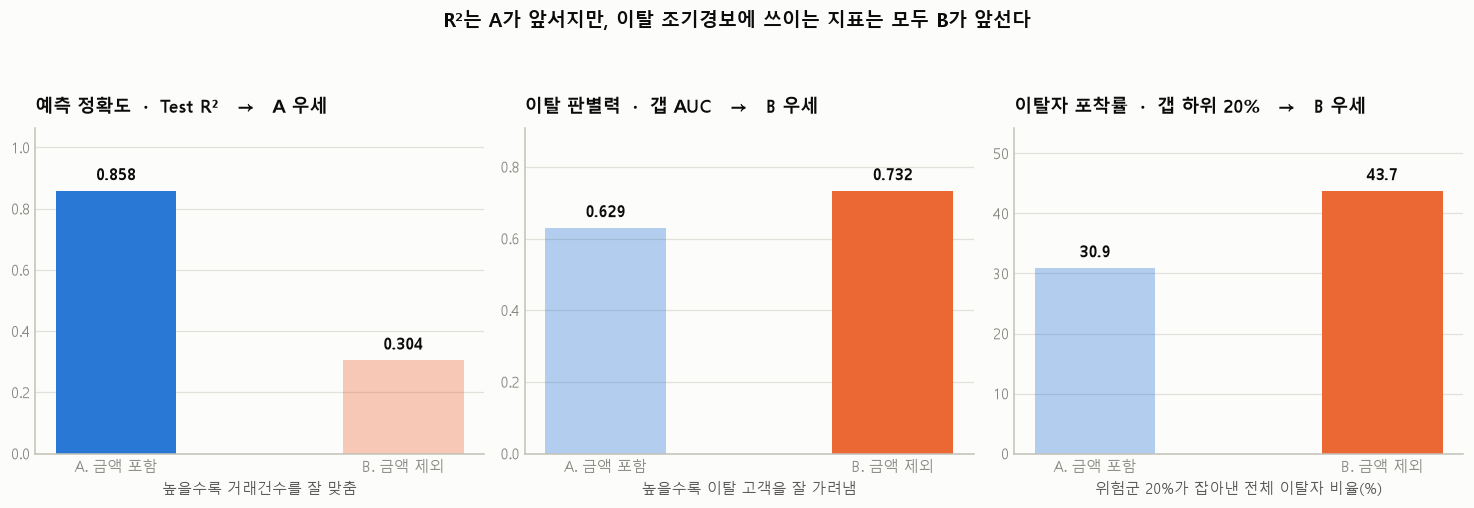

In [14]:
# ── A vs B: 정확도 지표 하나와 조기경보 지표 둘을 나란히 ────────────────────────
# 척도가 다르므로 한 축에 겹치지 않고 패널을 나눈다(이중 축 금지). 색은 A=파랑, B=주황 고정.
panels = [("예측 정확도  ·  Test R²",      "Test_R2",          "{:.3f}", "높을수록 거래건수를 잘 맞춤"),
          ("이탈 판별력  ·  갭 AUC",        "AUC",              "{:.3f}", "높을수록 이탈 고객을 잘 가려냄"),
          ("이탈자 포착률  ·  갭 하위 20%", "하위20%_포착률(%)", "{:.1f}", "위험군 20%가 잡아낸 전체 이탈자 비율(%)")]
versions = ["A. 금액 포함", "B. 금액 제외"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, (title, col, fmt, sub) in zip(axes, panels):
    vals = [compare.loc[v, col] for v in versions]
    bars = ax.bar(versions, vals, color=[BLUE, ORANGE], width=0.42)
    win = int(np.argmax(vals))                      # 우세한 쪽만 진하게 (색=정체성, 투명도=강조)
    bars[1 - win].set_alpha(0.35)
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals], padding=5,
                 fontsize=10.5, fontweight="bold", color=INK)
    ax.set_ylim(0, max(vals) * 1.24)
    ax.set_title(f"{title}   →   {versions[win].split('.')[0]} 우세", loc="left", fontsize=11.5)
    ax.set_xlabel(sub)
    style_ax(ax)

fig.suptitle("R²는 A가 앞서지만, 이탈 조기경보에 쓰이는 지표는 모두 B가 앞선다",
             y=0.995, fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**해석**: A는 Test R²가 훨씬 높지만, 그 성능은 대부분 `Total_Trans_Amt` 하나에서 온다(7번 importance).
반면 이탈 판별 지표(상관·AUC·포착률)는 **모두 B가 우세**하다. 목적이 이탈 조기경보라면 R²가 아니라 이쪽이 맞는 잣대다.

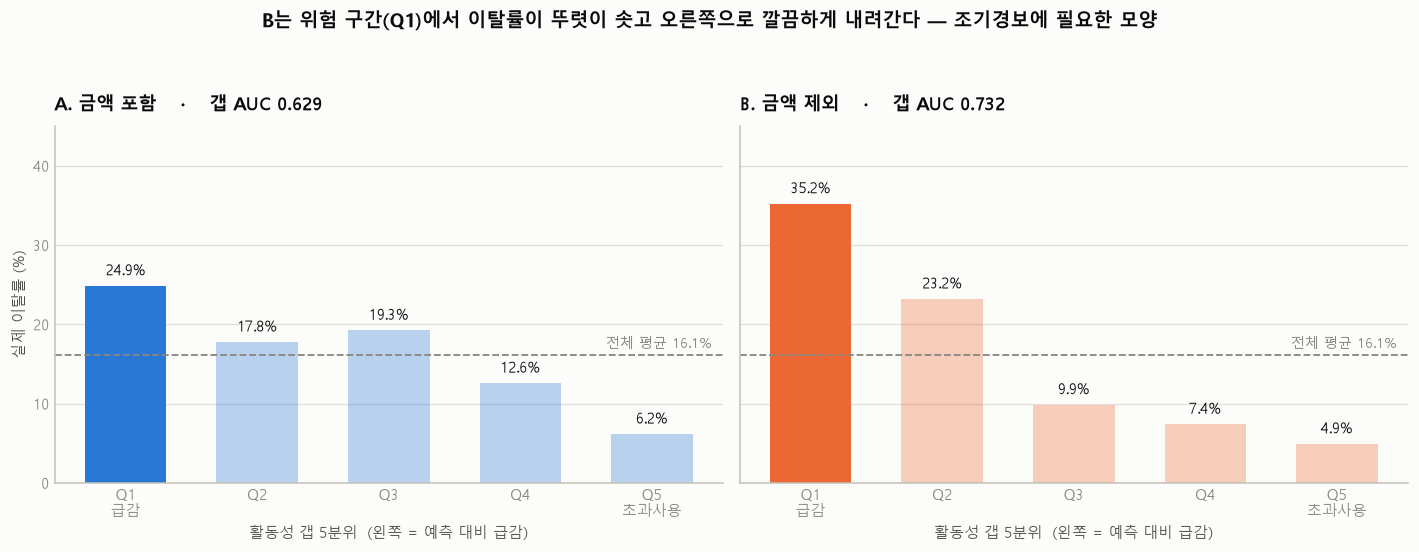

In [15]:
# ── 갭 5분위별 실제 이탈률 — 좋은 조기경보 = 왼쪽이 높고 오른쪽으로 단조 감소 ──────
labels = ["Q1\n급감", "Q2", "Q3", "Q4", "Q5\n초과사용"]
panels = [(gap_A, "A. 금액 포함", BLUE), (gap_B, "B. 금액 제외", ORANGE)]

rates = []
for g, _, _ in panels:
    q = pd.qcut(g["활동성_갭"], 5, labels=labels)
    rates.append(g.groupby(q, observed=True)["실제_이탈여부"].mean() * 100)
ymax = max(r.max() for r in rates) * 1.28

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (g, title, c), rate in zip(axes, panels, rates):
    bars = ax.bar(range(5), rate.values, color=c, width=0.62)
    for i, bar in enumerate(bars):
        if i:                      # 위험 구간(Q1)만 진하게, 나머지는 뒤로 물린다
            bar.set_alpha(0.32)
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in rate.values], padding=5,
                 fontsize=9.5, color=INK)
    base = g["실제_이탈여부"].mean() * 100
    ax.axhline(base, color=MUTED, ls="--", lw=1.2, zorder=1)      # 임계선이라 파선 (그리드는 실선)
    ax.text(4.45, base + ymax * 0.02, f"전체 평균 {base:.1f}%",
            ha="right", fontsize=9, color=MUTED)
    auc = roc_auc_score(g["실제_이탈여부"], -g["활동성_갭"])
    ax.set_title(f"{title}    ·    갭 AUC {auc:.3f}", loc="left")
    ax.set_xticks(range(5)); ax.set_xticklabels(labels)
    ax.set_xlabel("활동성 갭 5분위  (왼쪽 = 예측 대비 급감)")
    ax.set_ylim(0, ymax)
    style_ax(ax)

axes[0].set_ylabel("실제 이탈률 (%)")
fig.suptitle("B는 위험 구간(Q1)에서 이탈률이 뚜렷이 솟고 오른쪽으로 깔끔하게 내려간다 — 조기경보에 필요한 모양",
             y=0.995, fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 9. Ablation — 왜 R²가 0.3에 머무는가 (데이터의 한계 증명)

"금액을 빼면 R²가 낮다"는 약점을 파고들어, 그 원인이 **모델·튜닝이 아니라 데이터가 가진 정보의 한계**임을
세 실험으로 증명한다.

### 9-1. 파생변수를 더 넣으면 오르는가? → 거의 안 오름

In [16]:
def quick_r2(Xf):
    a,b,c,d_,e,f,_,_ = split_60_20_20(Xf)
    m = XGBRegressor(n_estimators=800, max_depth=6, learning_rate=0.02,
                     subsample=0.8, colsample_bytree=0.8, random_state=42).fit(a, d_)
    return r2_score(f, m.predict(c))

d2 = df.copy()
d2["revbal_per_limit"]=d2["Total_Revolving_Bal"]/d2["Credit_Limit"]
d2["otb_per_limit"]=d2["Avg_Open_To_Buy"]/d2["Credit_Limit"]
d2["limit_per_age"]=d2["Credit_Limit"]/d2["Customer_Age"]
d2["limit_per_rel"]=d2["Credit_Limit"]/d2["Total_Relationship_Count"]
d2["revbal_per_rel"]=d2["Total_Revolving_Bal"]/d2["Total_Relationship_Count"]
d2["age_x_rel"]=d2["Customer_Age"]*d2["Total_Relationship_Count"]
d2["util_x_rel"]=d2["Avg_Utilization_Ratio"]*d2["Total_Relationship_Count"]
d2["inactive_x_contact"]=d2["Months_Inactive_12_mon"]*d2["Contacts_Count_12_mon"]
d2["log_limit"]=np.log1p(d2["Credit_Limit"])
extra = ["revbal_per_limit","otb_per_limit","limit_per_age","limit_per_rel","revbal_per_rel",
         "age_x_rel","util_x_rel","inactive_x_contact","log_limit"]
X_B_base = make_features(drop_amount=True, fe=True)
X_B_more = pd.get_dummies(d2.drop(columns=["Total_Trans_Ct","Target","Total_Ct_Chng_Q4_Q1","Total_Trans_Amt"]),
                          columns=df.select_dtypes(include="object").columns.tolist(), drop_first=True)
pd.DataFrame([
    {"실험":"B. 금액 제외 baseline",   "피처수":X_B_base.shape[1], "Test_R2":quick_r2(X_B_base)},
    {"실험":"B + 파생변수 9개 추가",    "피처수":X_B_more.shape[1], "Test_R2":quick_r2(X_B_more)},
]).round(3)

,실험,피처수,Test_R2
0,B. 금액 제외 baseline,36,0.276
1,B + 파생변수 9개 추가,38,0.289


### 9-2. 타겟(Ct)을 재료로 쓰면? → R²는 치솟지만 **데이터 누수(반칙)**

파생변수 정당성 판별 기준: **"정답(Ct)을 모른 채 계산할 수 있는가?"** — 없으면 누수다.
`Amt/Ct`, `Amt*Ct`는 Ct가 있어야 계산되므로 실제 예측 시엔 쓸 수 없다.

In [17]:
def leak_r2(extra_col_name=None, series=None):
    """세 실험을 '같은 모델(XGB_BEST) · 같은 전처리'로 맞춰 비교한다 (추가 컬럼만 다름)."""
    d = df.copy()
    if extra_col_name is not None:
        d[extra_col_name] = series
    X = pd.get_dummies(d.drop(columns=["Total_Trans_Ct","Target","Total_Ct_Chng_Q4_Q1","Total_Trans_Amt"]),
                       columns=df.select_dtypes(include="object").columns.tolist(), drop_first=True)
    a,b,c,d_,e,f,_,_ = split_60_20_20(X)
    m = XGBRegressor(**XGB_BEST).fit(a, d_)
    return r2_score(f, m.predict(c))

leak_tbl = pd.DataFrame([
    {"실험":"B. 정상(누수 없음)",              "누수":False, "Test_R2": leak_r2()},
    {"실험":"+ avg_ticket = Amt / Ct  (누수)", "누수":True,  "Test_R2": leak_r2("avg_ticket", df["Total_Trans_Amt"]/df["Total_Trans_Ct"])},
    {"실험":"+ amt_x_ct   = Amt * Ct  (누수)", "누수":True,  "Test_R2": leak_r2("amt_x_ct",   df["Total_Trans_Amt"]*df["Total_Trans_Ct"])},
])
leak_tbl.round(3)

,실험,누수,Test_R2
0,B. 정상(누수 없음),False,0.302
1,+ avg_ticket = Amt / Ct (누수),True,0.535
2,+ amt_x_ct = Amt * Ct (누수),True,0.951


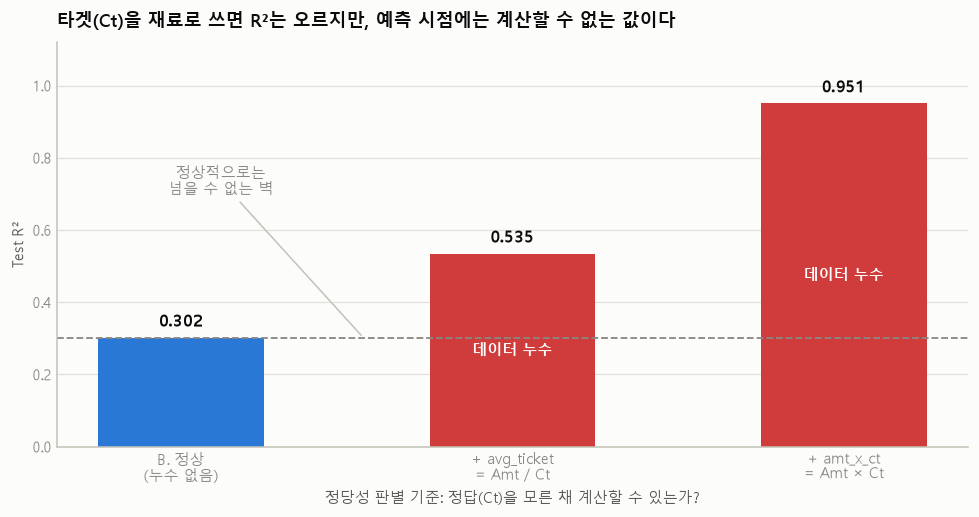

In [18]:
# ── 누수 피처를 넣으면 R²는 뚫리지만, 그 성능은 쓸 수 없는 성능이다 ─────────────
short = ["B. 정상\n(누수 없음)", "+ avg_ticket\n= Amt / Ct", "+ amt_x_ct\n= Amt × Ct"]
vals  = leak_tbl["Test_R2"].tolist()
# 색: 정상은 시리즈 색(파랑), 누수는 상태색(빨강) — 상태색은 라벨과 함께만 쓴다
cols  = [CRITICAL if leak else BLUE for leak in leak_tbl["누수"]]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(short, vals, color=cols, width=0.5)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=5,
             fontsize=11, fontweight="bold", color=INK)
for bar, leak in zip(bars, leak_tbl["누수"]):
    if leak:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, "데이터 누수",
                ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.axhline(vals[0], color=MUTED, ls="--", lw=1.2, zorder=1)
ax.annotate("정상적으로는\n넘을 수 없는 벽", xy=(0.55, vals[0]), xytext=(0.12, 0.70),
            ha="center", fontsize=9.5, color=MUTED,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=1))
ax.set_ylim(0, 1.12)
ax.set_ylabel("Test R²")
ax.set_title("타겟(Ct)을 재료로 쓰면 R²는 오르지만, 예측 시점에는 계산할 수 없는 값이다", loc="left", fontsize=11.5)
ax.set_xlabel("정당성 판별 기준: 정답(Ct)을 모른 채 계산할 수 있는가?")
style_ax(ax)
fig.tight_layout(); plt.show()

→ `Amt*Ct`는 R² 0.95까지 나오지만 **타겟을 곱한 가짜 성능**이다. 실무·평가에서 이런 피처는 반드시 제외한다.

### 9-3. 타겟을 거래금액으로 바꾸면? → 벽이 거울처럼 반복

금액을 타겟으로 삼으면 이번엔 **거래건수가 새로운 쌍둥이**가 된다. 쌍둥이를 빼면 R²는 다시 0.3~0.4로 내려가고,
갭의 이탈 판별력(AUC)은 오히려 건수 타겟보다 낮다.

In [19]:
def target_exp(target, drop_twin):
    yy = df[target]
    drop = ["Target", target]
    if drop_twin:
        drop += ["Total_Trans_Ct","Total_Trans_Amt","Total_Ct_Chng_Q4_Q1"]
    else:
        drop += ["Total_Ct_Chng_Q4_Q1"] if target=="Total_Trans_Ct" else []
    X = pd.get_dummies(df.drop(columns=list(set(drop))),
                       columns=df.select_dtypes(include="object").columns.tolist(), drop_first=True)
    Xtv2,Xte2,ytv2,yte2 = train_test_split(X, yy, test_size=0.2, random_state=42)
    Xtr2,Xva2,ytr2,yva2 = train_test_split(Xtv2, ytv2, test_size=0.25, random_state=42)
    m = XGBRegressor(**XGB_BEST).fit(Xtr2, ytr2)
    gap = yte2.values - m.predict(Xte2); churn = df.loc[Xte2.index,"Target"].values
    return r2_score(yte2, m.predict(Xte2)), roc_auc_score(churn, -gap)

rows = []
for tgt, name in [("Total_Trans_Ct","거래건수"), ("Total_Trans_Amt","거래금액")]:
    for tw, lab in [(False,"금액/건수 포함"), (True,"금액/건수 제외")]:
        r2v, aucv = target_exp(tgt, tw)
        rows.append({"타겟":name, "구성":lab, "Test_R2":r2v, "갭_AUC":aucv})
tgt_tbl = pd.DataFrame(rows)
tgt_tbl.round(3)

,타겟,구성,Test_R2,갭_AUC
0,거래건수,금액/건수 포함,0.856,0.638
1,거래건수,금액/건수 제외,0.302,0.729
2,거래금액,금액/건수 포함,0.861,0.368
3,거래금액,금액/건수 제외,0.361,0.637


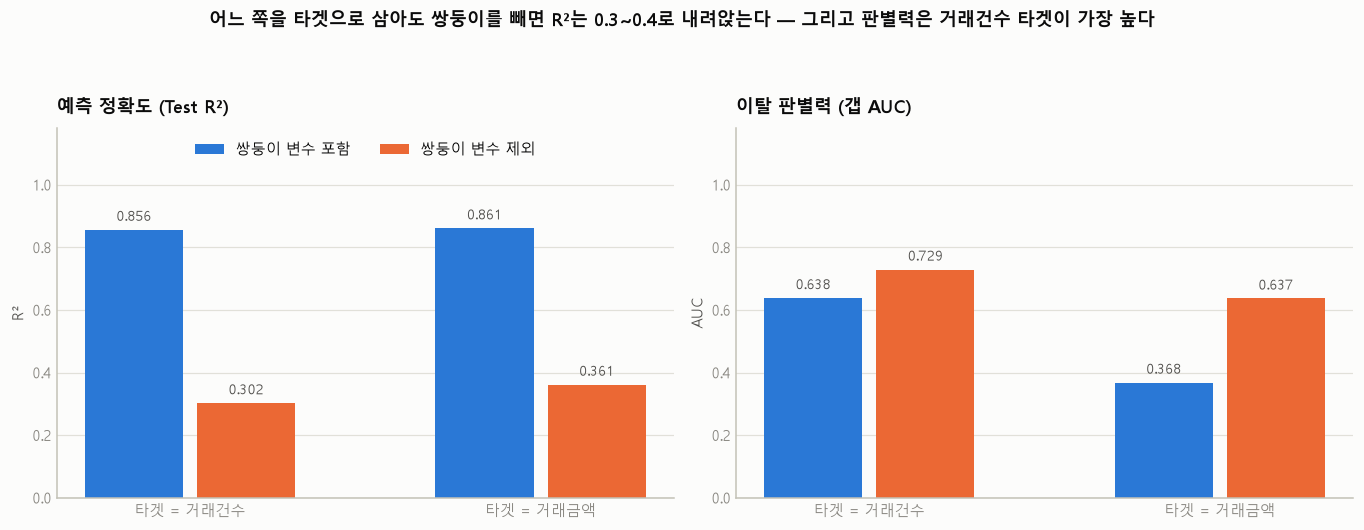

In [20]:
# ── 타겟을 바꿔도 같은 벽이 반복된다 (쌍둥이 변수를 빼는 순간 R²가 무너짐) ────────
order = ["거래건스", "거래금액"] if False else ["거래건수", "거래금액"]
x, w = np.arange(2), 0.28
metrics = [("Test_R2", "예측 정확도 (Test R²)", "R²"),
           ("갭_AUC",  "이탈 판별력 (갭 AUC)",  "AUC")]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, (col, title, ylab) in zip(axes, metrics):
    inc = tgt_tbl[tgt_tbl["구성"] == "금액/건수 포함"].set_index("타겟")[col].reindex(order)
    exc = tgt_tbl[tgt_tbl["구성"] == "금액/건수 제외"].set_index("타겟")[col].reindex(order)
    b1 = ax.bar(x - 0.16, inc.values, w, color=BLUE,   label="쌍둥이 변수 포함")
    b2 = ax.bar(x + 0.16, exc.values, w, color=ORANGE, label="쌍둥이 변수 제외")
    for bars in (b1, b2):
        ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9, color=INK_SUB)
    ax.set_xticks(x); ax.set_xticklabels([f"타겟 = {o}" for o in order])
    ax.set_ylim(0, 1.18); ax.set_ylabel(ylab)
    ax.set_title(title, loc="left")
    style_ax(ax)
axes[0].legend(loc="upper center", ncol=2)

fig.suptitle("어느 쪽을 타겟으로 삼아도 쌍둥이를 빼면 R²는 0.3~0.4로 내려앉는다 — 그리고 판별력은 거래건수 타겟이 가장 높다",
             y=0.995, fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Ablation 결론**: 파생변수·타겟교체 어느 쪽으로도 R²는 못 올린다. 합법적으로 R²를 올리는 유일한 정보원이
타겟 자신(또는 그 사본인 금액)뿐이기 때문. **즉 0.3은 이 스냅샷 데이터의 정보 한계이지 모델·튜닝의 실패가 아니다.**
그리고 이탈 판별력(갭 AUC)은 거래건수 타겟이 가장 높아, **현재 타겟 선택이 목적에 맞다.**

## 10. 최종 선택 & 비즈니스 적용 — 활동성 갭 조기경보 (모델 B)

이탈 조기경보라는 목적에 따라 **최종적으로 모델 B(금액 제외)** 를 사용한다.
### 활동성 갭 = 실제 거래건수 − 예측 거래건수
갭이 큰 음수 = "이 고객의 이용 패턴이면 이만큼 써야 하는데 유독 덜 쓴다" → 이탈 위험.

In [21]:
gapB = gap_B.copy()   # 8번에서 계산한 모델 B의 Test 갭
print("활동성 갭 요약:")
display(gapB["활동성_갭"].describe().round(2).to_frame().T)

# 조기경보 Top10 (갭 최소) vs 우량고객 Top10 (갭 최대)
warn  = gapB.sort_values("활동성_갭").head(10)
loyal = gapB.sort_values("활동성_갭", ascending=False).head(10)
print("\n[조기경보 Top10] 평균 갭 {:.1f} / 실제 이탈률 {:.1f}%".format(
    warn["활동성_갭"].mean(), warn["실제_이탈여부"].mean()*100))
print("[우량고객 Top10] 평균 갭 {:.1f} / 실제 이탈률 {:.1f}%".format(
    loyal["활동성_갭"].mean(), loyal["실제_이탈여부"].mean()*100))

활동성 갭 요약:


,count,mean,std,min,25%,50%,75%,max
활동성_갭,2026.0,-0.05,19.3,-73.87,-12.56,1.26,12.72,66.43



[조기경보 Top10] 평균 갭 -60.1 / 실제 이탈률 60.0%
[우량고객 Top10] 평균 갭 58.7 / 실제 이탈률 0.0%


In [22]:
# 갭을 이탈 점수로 본 판별력 지표 + (가능하면) feature importance
churnB = gapB["실제_이탈여부"].values
print("갭-이탈 상관 : {:.3f}".format(np.corrcoef(gapB["활동성_갭"], churnB)[0,1]))
print("갭 AUC       : {:.3f}".format(roc_auc_score(churnB, -gapB["활동성_갭"])))
thr = np.quantile(gapB["활동성_갭"], 0.2); flag = gapB["활동성_갭"] <= thr
print("하위20% 위험군 → 전체 이탈자의 {:.0f}% 포착, 위험군 정확도 {:.0f}%".format(
    churnB[flag.values].sum()/churnB.sum()*100, churnB[flag.values].mean()*100))

# 최종 모델 B가 앙상블(Voting/Stacking)이면 단일 feature_importances_가 없다.
# 이 경우 permutation importance로 '무엇을 보는지'를 확인한다.
print(f"\n[모델 B = {best_B}] 예측 근거 Top8 (이용·관계 패턴 위주):")
if hasattr(model_B, "feature_importances_"):
    impB = pd.Series(model_B.feature_importances_, index=X_Ball.columns)
else:
    from sklearn.inspection import permutation_importance
    Xva_B, yva_B = spB[1], spB[4]
    pim = permutation_importance(model_B, Xva_B, yva_B, n_repeats=5, random_state=42)
    impB = pd.Series(pim.importances_mean, index=X_Ball.columns)
print(impB.sort_values(ascending=False).head(8).round(3).to_string())

갭-이탈 상관 : -0.290
갭 AUC       : 0.732
하위20% 위험군 → 전체 이탈자의 44% 포착, 위험군 정확도 35%

[모델 B = Voting] 예측 근거 Top8 (이용·관계 패턴 위주):
Total_Amt_Chng_Q4_Q1        0.172
Total_Relationship_Count    0.136
Total_Revolving_Bal         0.070
Contacts_Count_12_mon       0.044
Customer_Age                0.039
Marital_Status_Married      0.035
Credit_Limit                0.016
문의_대비_보유기간                  0.015


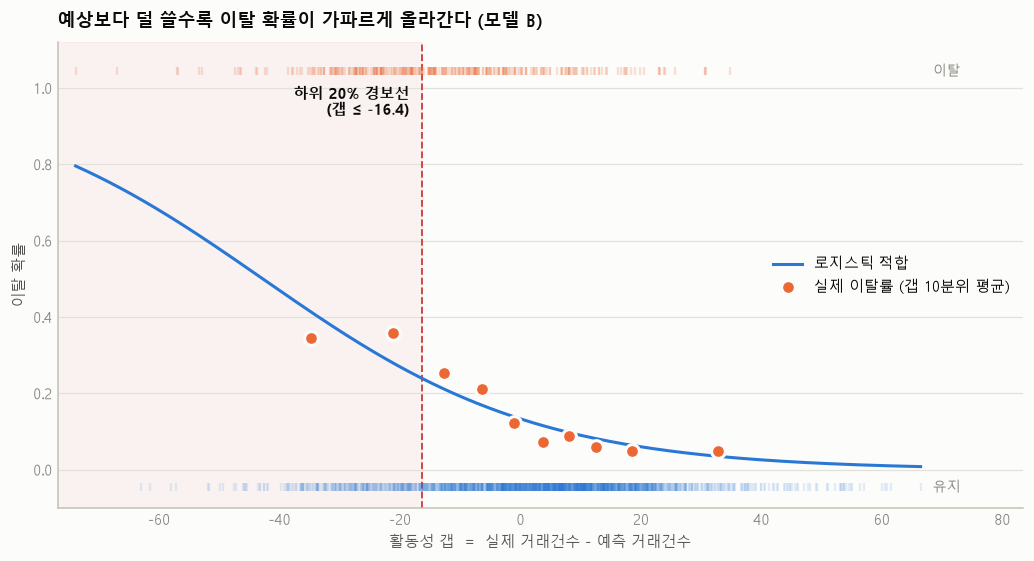

In [23]:
# ── 갭 → 이탈확률 (모델 B) : 적합 곡선 + 실제 관측치를 함께 놓는다 ───────────────
gvals = gapB["활동성_갭"].values
logit = LogisticRegression().fit(gvals.reshape(-1, 1), churnB)
xs = np.linspace(gvals.min(), gvals.max(), 300).reshape(-1, 1)
ps = logit.predict_proba(xs)[:, 1]

# 실측: 갭 10분위별 실제 이탈률 (곡선이 데이터를 따라가는지 눈으로 확인)
obs = (gapB.assign(_b=pd.qcut(gapB["활동성_갭"], 10))
            .groupby("_b", observed=True)
            .agg(x=("활동성_갭", "mean"), y=("실제_이탈여부", "mean")))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
thr = np.quantile(gvals, 0.2)
ax.axvspan(gvals.min() - 3, thr, color=CRITICAL, alpha=0.05, zorder=0)
ax.axvline(thr, color=CRITICAL, ls="--", lw=1.2, zorder=1)
ax.text(thr - 2, 0.93, f"하위 20% 경보선\n(갭 ≤ {thr:.1f})",
        ha="right", fontsize=9.5, color=INK, fontweight="bold")

# 개별 고객은 러그로만 (0/1 산점도는 겹쳐서 읽히지 않는다)
ax.scatter(gvals[churnB == 1], np.full((churnB == 1).sum(), 1.045),
           marker="|", s=22, color=ORANGE, alpha=0.20, zorder=2)
ax.scatter(gvals[churnB == 0], np.full((churnB == 0).sum(), -0.045),
           marker="|", s=22, color=BLUE, alpha=0.12, zorder=2)
ax.text(gvals.max() + 2, 1.045, "이탈", va="center", fontsize=9, color=MUTED)
ax.text(gvals.max() + 2, -0.045, "유지", va="center", fontsize=9, color=MUTED)

ax.plot(xs, ps, color=BLUE, lw=2, zorder=3, label="로지스틱 적합")
ax.plot(obs["x"], obs["y"], "o", ms=9, color=ORANGE, mec=SURFACE, mew=2, zorder=4,
        label="실제 이탈률 (갭 10분위 평균)")

ax.set_xlim(gvals.min() - 3, gvals.max() + 17)
ax.set_ylim(-0.10, 1.12)
ax.set_xlabel("활동성 갭  =  실제 거래건수 - 예측 거래건수")
ax.set_ylabel("이탈 확률")
ax.set_title("예상보다 덜 쓸수록 이탈 확률이 가파르게 올라간다 (모델 B)", loc="left")
ax.legend(loc="center right")
style_ax(ax)
fig.tight_layout(); plt.show()

## 11. 결론

| 관점 | 최종 선택 | 근거 |
|---|---|---|
| 거래건수 예측 정확도 | A. 금액 포함 | Test R² ≈ 0.86 (단, 대부분 `Total_Trans_Amt` 기여 = 착시) |
| **이탈 조기경보(본 프로젝트 목적)** | **B. 금액 제외** | 갭-이탈 상관·AUC·포착률 모두 우세 |

- **R²가 높다고 좋은 모델이 아니다.** A의 높은 R²는 타겟과 동어반복인 거래금액에서 온다.
- **R² 0.3은 데이터의 정보 한계** — 파생변수·타겟교체로 못 넘고, 넘으려면 타겟 누수(반칙)뿐임을 Ablation으로 증명.
- 목적(이탈 조기경보)에는 **모델 B**가 적합. "예상 이용 패턴 대비 거래건수 급감"을 더 잘 잡아낸다(AUC 0.73, 하위20%로 이탈자 43% 포착).
- **실무 적용**: 매달 B로 활동성 갭을 재계산 → 갭 하위 구간 고객에게 선제적 리텐션(포인트 2배·사용 유도), 갭 상위 고객은 업셀링 대상.

## 12. 전체 고객 활동성 갭을 OOF로 계산 후 pickle 저장

조기경보는 **전체 고객**에게 매기는데, Train(80%)으로 학습한 모델을 그 Train 고객에게 그대로 예측하면 '이미 본 데이터'라 갭이 인위적으로 작게 나온다(편향). 이를 막기 위해 **OOF(Out-Of-Fold)** 를 쓴다.

- 전체를 5조각(fold)으로 나누고, 각 고객을 예측할 때는 **그 고객이 빠진 나머지 4조각**으로 학습한 모델을 쓴다. → 모든 고객이 '자기가 학습에 안 들어간 모델'의 예측을 받아 공평해진다.
- 최종 모델이 **Voting**인 이유: Stacking은 내부 교차검증(cv)이 OOF 바깥 교차검증과 중첩되면 예측이 무너져(OOF R²가 음수) 전체 고객 적용에 부적합하다. Voting은 이 문제가 없다.
- 저장은 파이썬 기본 내장 `pickle`만 사용한다 (다른 노트북에서 `pickle.load()`로 바로 읽음).

In [24]:
import pickle

# 전체 고객(X_Ball, y_all)에 대해 5-fold OOF 예측 → 전원이 out-of-sample
y_all_B = df["Total_Trans_Ct"]
oof_estimator = make_estimator(best_B)          # best_B는 Voting(=OOF 안전 후보)
kf = KFold(n_splits=5, shuffle=True, random_state=42)   # 데이터가 타깃순 정렬이라 shuffle 필수
oof_pred = cross_val_predict(oof_estimator, X_Ball, y_all_B, cv=kf, n_jobs=1)

from sklearn.metrics import r2_score as _r2
print(f"전체 고객 OOF R2: {_r2(y_all_B, oof_pred):.4f}  (Test R2와 비슷하면 편향 없이 잘 일반화된 것)")

gap_result_B = pd.DataFrame({
    "예측_거래건수_B": oof_pred,
    "활동성_갭_B": y_all_B.values - oof_pred,
}, index=df.index)

with open("../outputs/gap_result/gap_result_B.pkl", "wb") as f:
    pickle.dump(gap_result_B, f)

print("저장 완료: gap_result_B.pkl (Voting 기반 OOF, pickle 기본 모듈)")
print("shape:", gap_result_B.shape)
gap_result_B.head()

전체 고객 OOF R2: 0.3186  (Test R2와 비슷하면 편향 없이 잘 일반화된 것)
저장 완료: gap_result_B.pkl (Voting 기반 OOF, pickle 기본 모듈)
shape: (10127, 2)


,예측_거래건수_B,활동성_갭_B
0,50.487005,-8.487005
1,51.922471,-18.922471
2,31.668229,-11.668229
3,51.086685,-31.086685
4,33.293016,-5.293016
